# Predicting Patient Insurance Costs (Regression Modeling)

**Dixin Zhang**

Date: 2026.01.25

**Course topic:** Supervised machine learning with regression (scikit-learn)  
**Dataset:** `MedicalInsurance.csv` (age, sex, bmi, children, smoker, region → charges)  
**Target variable:** `charges` (patient insurance costs, in dollars)  

# `Import necessary libraries`

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, RepeatedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

from IPython.display import display

# Reproducibility
RANDOM_STATE = 42


# `Load dataset & initial EDA`

--- Dataset Overview ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Shape ---
(1338, 7)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

--- Missing Values ---


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


--- Duplicate Rows ---
1

--- Summary Statistics (numeric) ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


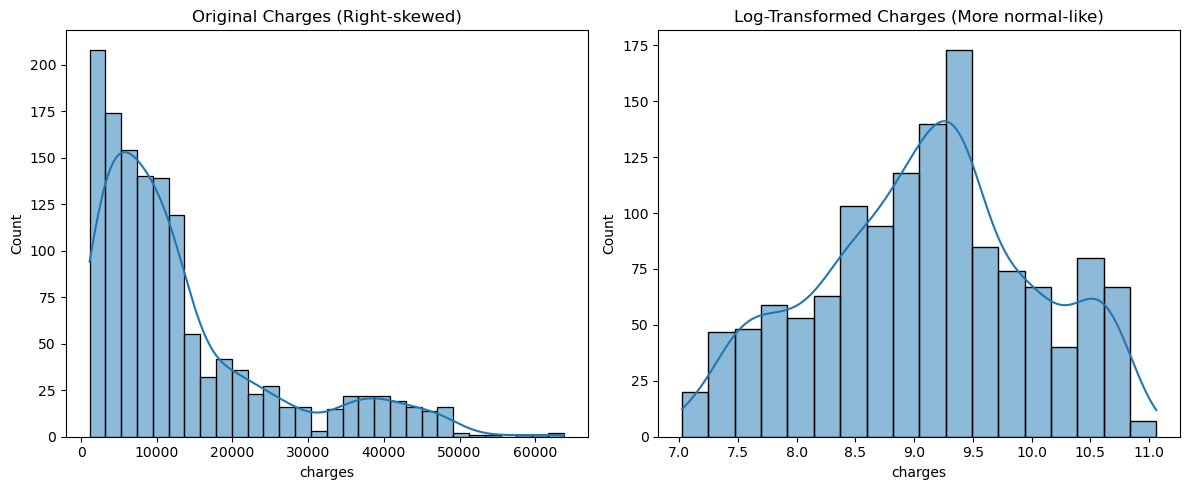

Observation: 'charges' is strongly right-skewed; log1p(charges) often helps many regression models.
Median charges: 9382.033
Mean charges: 13270.422265141257


In [3]:
csv_path = "MedicalInsurance.csv"

df = pd.read_csv(csv_path)

print("--- Dataset Overview ---")
display(df.head())

print("\n--- Shape ---")
print(df.shape)

print("\n--- Info ---")
print(df.info())

print("\n--- Missing Values ---")
display(df.isna().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Summary Statistics (numeric) ---")
display(df.describe())

# --- Target distribution (charges) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["charges"], kde=True)
plt.title("Original Charges (Right-skewed)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df["charges"]), kde=True)
plt.title("Log-Transformed Charges (More normal-like)")

plt.tight_layout()
plt.show()

print("Observation: 'charges' is strongly right-skewed; log1p(charges) often helps many regression models.")
print("Median charges:", float(df["charges"].median()))
print("Mean charges:", float(df["charges"].mean()))


# `EDA: key relationships`

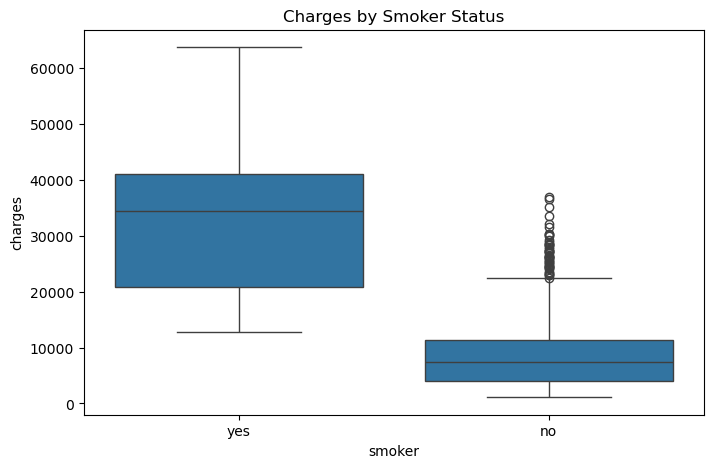

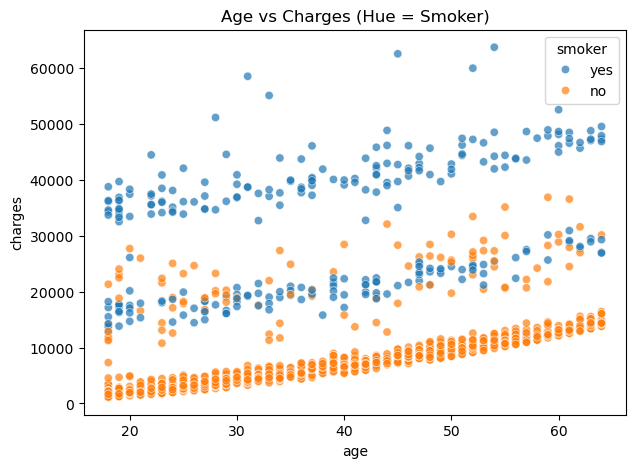

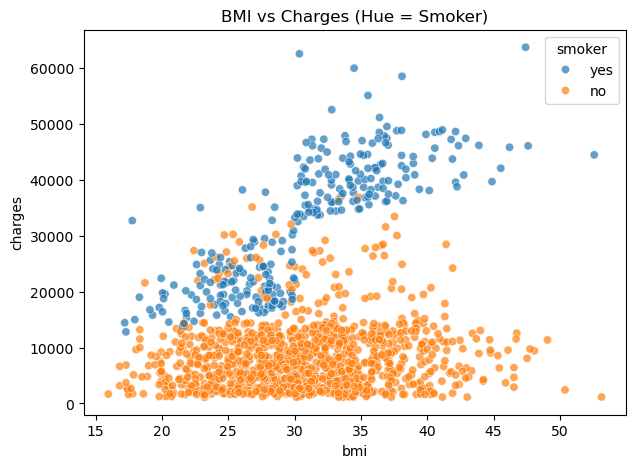

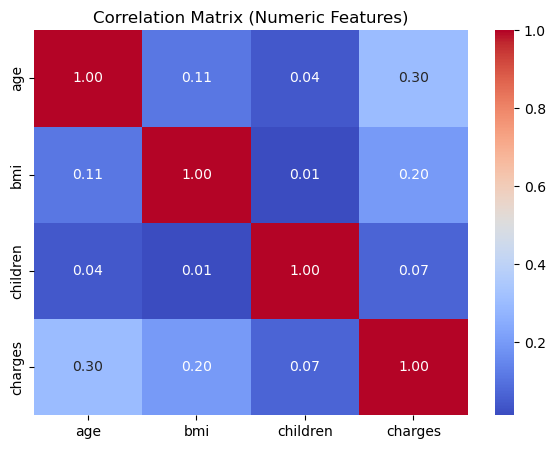

In [4]:
# Smoker vs Charges (this is usually the strongest driver)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges by Smoker Status")
plt.show()

# Age / BMI vs Charges (colored by smoker)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7)
plt.title("Age vs Charges (Hue = Smoker)")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7)
plt.title("BMI vs Charges (Hue = Smoker)")
plt.show()

# Correlation heatmap (numeric features only)
plt.figure(figsize=(7, 5))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()


# `Preprocessing`

In [5]:
# Features (X) and target (y)
X = df.drop(columns=["charges"])
y = df["charges"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Preprocessing pipeline:
# - Numerical: median imputation + StandardScaler
# - Categorical: mode imputation + OneHotEncoder
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numerical_cols),
        ("cat", cat_pipe, categorical_cols),
    ],
    remainder="drop"
)

# Models (include a baseline)
# Notes:
# - We keep a simple DummyRegressor as a "do-nothing" baseline.
# - We include both linear and non-linear models for comparison.
models = {
    "Baseline (Dummy Mean)": DummyRegressor(strategy="mean"),
    "Linear Regression (log target)": LinearRegression(),
    "Ridge (log target)": Ridge(),
    "Lasso (log target)": Lasso(max_iter=30000),
    "ElasticNet (log target)": ElasticNet(max_iter=30000),
    "KNN (log target)": KNeighborsRegressor(n_neighbors=15),
    "Gradient Boosting (log target)": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Random Forest (log target)": RandomForestRegressor(
        n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Extra Trees (log target)": ExtraTreesRegressor(
        n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1
    ),
}


Categorical columns: ['sex', 'smoker', 'region']
Numerical columns: ['age', 'bmi', 'children']


# `Modeling (baseline): Train/Test Split Evaluation`

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

holdout_results = []
fitted_pipes = {}

for name, model in models.items():
    # Baseline is trained directly on original charges (no log transform)
    if name.startswith("Baseline"):
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("regressor", model),
        ])
    else:
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("regressor", TransformedTargetRegressor(
                regressor=model,
                func=np.log1p,
                inverse_func=np.expm1
            )),
        ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    holdout_results.append({
        "Model": name,
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
    })
    fitted_pipes[name] = pipe

holdout_df = pd.DataFrame(holdout_results).sort_values(by="R2", ascending=False)

print("--- Holdout (80/20) Results ---")
display(holdout_df)

best_model_name = holdout_df.iloc[0]["Model"]
print("Best model on this holdout split:", best_model_name)


--- Holdout (80/20) Results ---


,Model,R2,MAE,RMSE
7,Random Forest (log target),0.873482,2074.178344,4431.898604
6,Gradient Boosting (log target),0.872565,2057.149873,4447.935092
8,Extra Trees (log target),0.853135,2167.870735,4774.989801
5,KNN (log target),0.624177,4025.972152,7638.458513
2,Ridge (log target),0.610058,3881.879523,7780.621059
1,Linear Regression (log target),0.606698,3888.443159,7814.064026
0,Baseline (Dummy Mean),-0.000919,9593.338461,12465.610442
4,ElasticNet (log target),-0.097591,8603.157345,13053.719350
3,Lasso (log target),-0.097591,8603.157345,13053.719350


Best model on this holdout split: Random Forest (log target)


# `Optimization: Changing the Testing Strategy`

In [7]:
# Strategy A: Try multiple holdout strategies (different test_size / random_state)
# This shows how sensitive results are to the testing strategy.
testing_strategies = [
    {"test_size": 0.2, "random_state": 42},
    {"test_size": 0.25, "random_state": 42},
    {"test_size": 0.3, "random_state": 42},
    {"test_size": 0.2, "random_state": 7},
    {"test_size": 0.2, "random_state": 99},
]

# Choose a candidate model to stress-test
# (Usually you would stress-test your top model.)
candidate_name = best_model_name
candidate_model = models[candidate_name]

strategy_rows = []

for s in testing_strategies:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=s["test_size"], random_state=s["random_state"]
    )

    if candidate_name.startswith("Baseline"):
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("regressor", candidate_model),
        ])
    else:
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("regressor", TransformedTargetRegressor(
                regressor=candidate_model,
                func=np.log1p,
                inverse_func=np.expm1
            )),
        ])

    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)

    strategy_rows.append({
        "Model": candidate_name,
        "test_size": s["test_size"],
        "random_state": s["random_state"],
        "R2": r2_score(y_te, preds),
        "MAE": mean_absolute_error(y_te, preds),
        "RMSE": np.sqrt(mean_squared_error(y_te, preds)),
    })

strategy_df = pd.DataFrame(strategy_rows).sort_values(by="R2", ascending=False)
print("--- Different Train/Test Strategies (same model) ---")
display(strategy_df)

print("Takeaway: a model can look better/worse depending on how the train/test split is done.")


--- Different Train/Test Strategies (same model) ---


,Model,test_size,random_state,R2,MAE,RMSE
0,Random Forest (log target),0.20,42,0.873482,2074.178344,4431.898604
2,Random Forest (log target),0.30,42,0.867133,2078.501717,4413.787255
3,Random Forest (log target),0.20,7,0.860105,2289.121684,4730.843035
1,Random Forest (log target),0.25,42,0.859684,2137.080307,4601.356816
4,Random Forest (log target),0.20,99,0.832851,2370.524227,4849.238178


Takeaway: a model can look better/worse depending on how the train/test split is done.


# `Optimization: Cross-Validation (5-Fold CV)`

In [8]:
# Strategy B: Cross-validation (more stable estimate than a single holdout split)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rkfold = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

cv_rows = []
cv_rows_rep = []

for name, model in models.items():
    # Build pipeline (same logic as above)
    if name.startswith("Baseline"):
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("regressor", model),
        ])
    else:
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("regressor", TransformedTargetRegressor(
                regressor=model,
                func=np.log1p,
                inverse_func=np.expm1
            )),
        ])

    # KFold CV
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=kfold,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
        },
        return_train_score=False
    )
    cv_rows.append({
        "Model": name,
        "R2 (mean)": np.mean(scores["test_r2"]),
        "R2 (std)": np.std(scores["test_r2"]),
        "MAE (mean)": -np.mean(scores["test_mae"]),
        "MAE (std)": np.std(-scores["test_mae"]),
        "RMSE (mean)": -np.mean(scores["test_rmse"]),
        "RMSE (std)": np.std(-scores["test_rmse"]),
    })

    # RepeatedKFold CV (more stable, but slower)
    scores_rep = cross_validate(
        pipe,
        X,
        y,
        cv=rkfold,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
        },
        return_train_score=False
    )
    cv_rows_rep.append({
        "Model": name,
        "R2 (mean)": np.mean(scores_rep["test_r2"]),
        "R2 (std)": np.std(scores_rep["test_r2"]),
        "MAE (mean)": -np.mean(scores_rep["test_mae"]),
        "MAE (std)": np.std(-scores_rep["test_mae"]),
        "RMSE (mean)": -np.mean(scores_rep["test_rmse"]),
        "RMSE (std)": np.std(-scores_rep["test_rmse"]),
    })

cv_df = pd.DataFrame(cv_rows).sort_values(by="R2 (mean)", ascending=False)
cv_rep_df = pd.DataFrame(cv_rows_rep).sort_values(by="R2 (mean)", ascending=False)

print("--- 5-Fold CV Results (KFold) ---")
display(cv_df)

print("--- 5-Fold CV Results (RepeatedKFold: 5 folds × 3 repeats) ---")
display(cv_rep_df)


--- 5-Fold CV Results (KFold) ---


,Model,R2 (mean),R2 (std),MAE (mean),MAE (std),RMSE (mean),RMSE (std)
7,Random Forest (log target),0.849962,0.030830,2174.272494,75.556030,4624.447142,265.787295
6,Gradient Boosting (log target),0.848776,0.031833,2174.948279,126.780842,4641.174506,305.335699
8,Extra Trees (log target),0.829086,0.029936,2302.223691,101.268125,4946.937230,248.232172
5,KNN (log target),0.581621,0.030989,4128.166601,237.540443,7789.545087,376.434548
2,Ridge (log target),0.511323,0.099820,4241.278254,258.517911,8361.904752,653.052624
1,Linear Regression (log target),0.507514,0.100721,4251.884137,262.410783,8394.538324,661.547466
0,Baseline (Dummy Mean),-0.002462,0.002396,9090.994473,542.603939,12085.703777,767.359808
4,ElasticNet (log target),-0.129659,0.026563,8363.399564,452.443397,12829.667453,844.139515
3,Lasso (log target),-0.129659,0.026563,8363.399564,452.443397,12829.667453,844.139515


--- 5-Fold CV Results (RepeatedKFold: 5 folds × 3 repeats) ---


,Model,R2 (mean),R2 (std),MAE (mean),MAE (std),RMSE (mean),RMSE (std)
7,Random Forest (log target),0.850017,0.039211,2188.310561,232.575990,4609.139058,513.888990
6,Gradient Boosting (log target),0.849926,0.040553,2176.529833,241.772868,4607.187918,534.349422
8,Extra Trees (log target),0.831094,0.036229,2278.802450,211.837289,4906.968951,428.977581
5,KNN (log target),0.574455,0.039537,4155.216810,342.019157,7857.573670,439.335858
2,Ridge (log target),0.511597,0.091708,4246.874620,320.577730,8372.614165,612.086939
1,Linear Regression (log target),0.507773,0.092434,4257.619340,324.053030,8405.440509,616.771354
0,Baseline (Dummy Mean),-0.005119,0.007461,9099.272375,455.456276,12098.935800,647.578385
4,ElasticNet (log target),-0.130712,0.040659,8366.427881,557.668290,12835.719460,807.612626
3,Lasso (log target),-0.130862,0.040628,8368.969187,554.589919,12836.530941,806.959954


# `Optimization: Hyperparameter Tuning (GridSearchCV)`

In [9]:
# We'll tune a few key hyperparameters and then evaluate on the SAME holdout test set for fair comparison.

# 1) Ridge and Lasso (alpha)
ridge_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", TransformedTargetRegressor(
        regressor=Ridge(),
        func=np.log1p,
        inverse_func=np.expm1
    )),
])

lasso_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", TransformedTargetRegressor(
        regressor=Lasso(max_iter=50000),
        func=np.log1p,
        inverse_func=np.expm1
    )),
])

param_grid_ridge = {
    "regressor__regressor__alpha": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
}
param_grid_lasso = {
    "regressor__regressor__alpha": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 0.1, 0.3, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_gs = GridSearchCV(
    ridge_pipe, param_grid=param_grid_ridge, cv=cv,
    scoring="neg_mean_absolute_error", n_jobs=-1
)
lasso_gs = GridSearchCV(
    lasso_pipe, param_grid=param_grid_lasso, cv=cv,
    scoring="neg_mean_absolute_error", n_jobs=-1
)

ridge_gs.fit(X_train, y_train)
lasso_gs.fit(X_train, y_train)

print("Best Ridge params:", ridge_gs.best_params_, " | CV MAE:", -ridge_gs.best_score_)
print("Best Lasso params:", lasso_gs.best_params_, " | CV MAE:", -lasso_gs.best_score_)

# 2) Gradient Boosting (a strong non-linear model) — tune with RandomizedSearchCV
gbr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", TransformedTargetRegressor(
        regressor=GradientBoostingRegressor(random_state=RANDOM_STATE),
        func=np.log1p,
        inverse_func=np.expm1
    )),
])

param_dist_gbr = {
    "regressor__regressor__n_estimators": [200, 300, 500, 800],
    "regressor__regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__regressor__max_depth": [2, 3, 4],
    "regressor__regressor__subsample": [0.6, 0.8, 1.0],
    "regressor__regressor__min_samples_leaf": [1, 3, 5, 10],
}

gbr_rs = RandomizedSearchCV(
    gbr_pipe,
    param_distributions=param_dist_gbr,
    n_iter=25,
    cv=cv,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gbr_rs.fit(X_train, y_train)
print("Best GBR params:", gbr_rs.best_params_, " | CV MAE:", -gbr_rs.best_score_)

# Evaluate tuned models on holdout test set
tuned_rows = []

for name, est in [
    ("Ridge (tuned)", ridge_gs.best_estimator_),
    ("Lasso (tuned)", lasso_gs.best_estimator_),
    ("Gradient Boosting (tuned)", gbr_rs.best_estimator_),
]:
    preds = est.predict(X_test)
    tuned_rows.append({
        "Model": name,
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
    })

tuned_df = pd.DataFrame(tuned_rows).sort_values(by="R2", ascending=False)
print("--- Tuned Model Results on Holdout Test Set ---")
display(tuned_df)


Best Ridge params: {'regressor__regressor__alpha': 30}  | CV MAE: 4026.8429788517847
Best Lasso params: {'regressor__regressor__alpha': 0.03}  | CV MAE: 3917.011246776937
Best GBR params: {'regressor__regressor__subsample': 0.6, 'regressor__regressor__n_estimators': 500, 'regressor__regressor__min_samples_leaf': 10, 'regressor__regressor__max_depth': 3, 'regressor__regressor__learning_rate': 0.01}  | CV MAE: 2125.6944255278167
--- Tuned Model Results on Holdout Test Set ---


,Model,R2,MAE,RMSE
2,Gradient Boosting (tuned),0.874919,1954.238846,4406.661748
0,Ridge (tuned),0.672521,3793.784699,7130.271222
1,Lasso (tuned),0.671979,3792.208185,7136.166486


# `Result interpretation: coefficients of the best linear model`

--- Top 12 coefficients for Ridge (trained on log1p(charges)) ---


,Feature,Coefficient,Abs_Coefficient
6,cat__smoker_yes,0.712859,0.712859
5,cat__smoker_no,-0.712859,0.712859
0,num__age,0.466359,0.466359
2,num__children,0.110925,0.110925
1,num__bmi,0.079570,0.079570
7,cat__region_northeast,0.070719,0.070719
9,cat__region_southeast,-0.047049,0.047049
10,cat__region_southwest,-0.041142,0.041142
3,cat__sex_female,0.031733,0.031733
4,cat__sex_male,-0.031733,0.031733


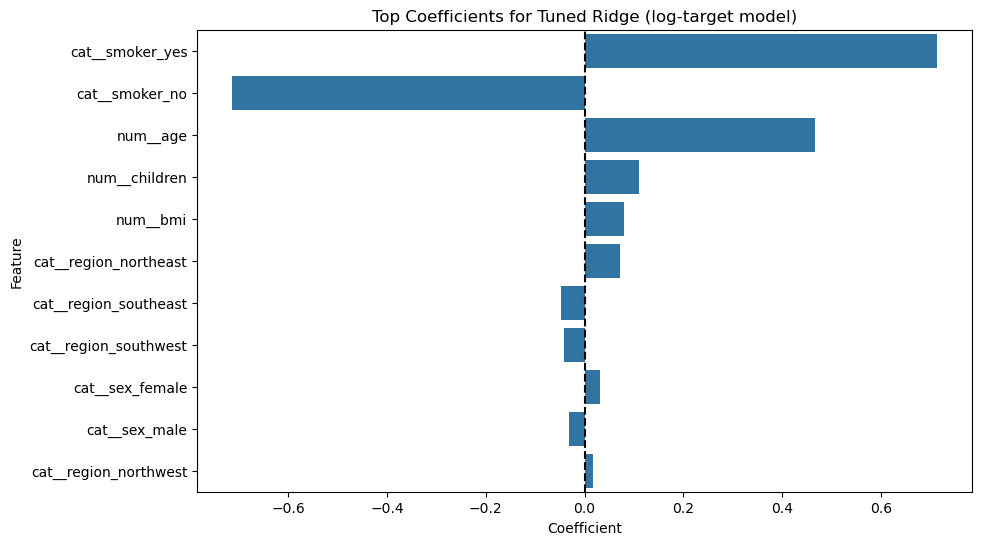

Interpretation tip: Because we trained on log1p(charges), coefficients reflect changes in log(charges).

Final selected model (lowest test MAE): Gradient Boosting (tuned)


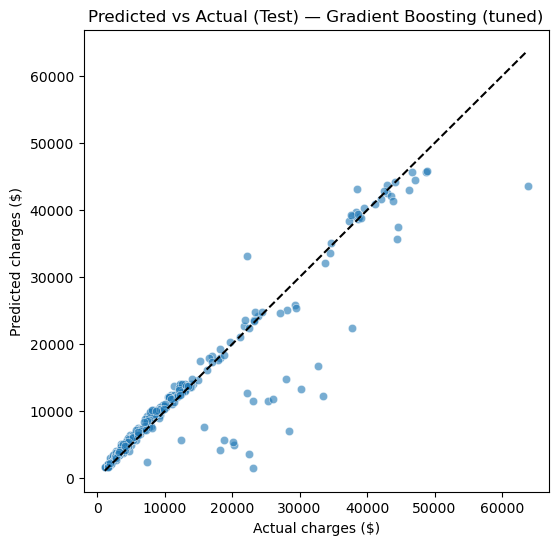

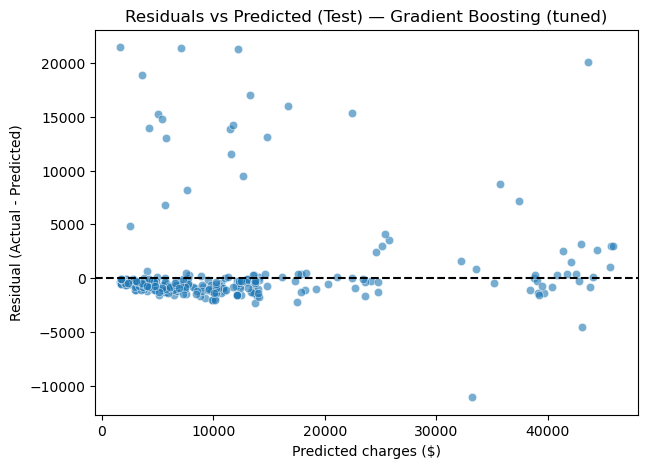

Test R2: 0.8749189924247275
Test MAE ($): 1954.2388458954185
Test RMSE ($): 4406.6617478283915

--- Top 12 permutation importances (higher = more important) ---


,Feature,Importance (MAE increase)
4,smoker,7078.501142
0,age,3145.550200
2,bmi,1725.239615
3,children,216.586688
5,region,26.039211
1,sex,20.653059


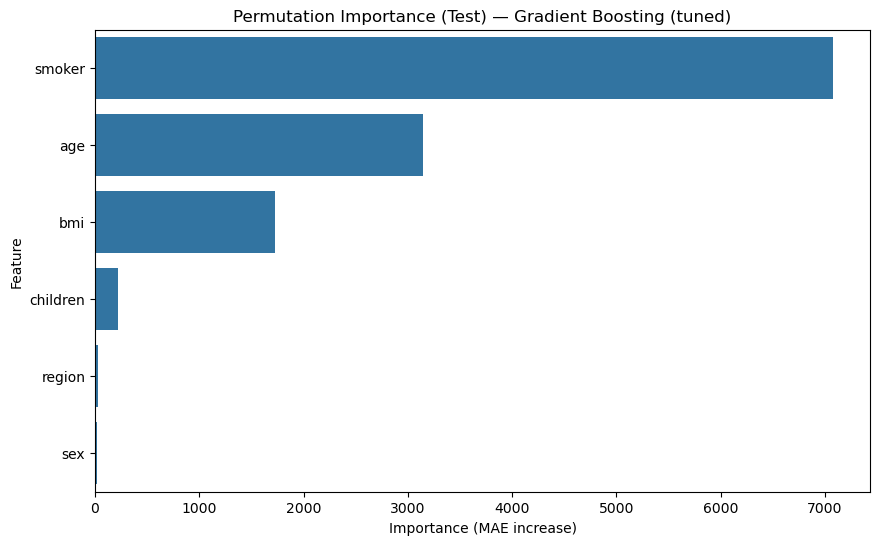

In [12]:
# --- Part A: Coefficients for a linear model (Ridge) ---
best_linear = ridge_gs.best_estimator_
feature_names = best_linear.named_steps["preprocessor"].get_feature_names_out()

fitted_reg = best_linear.named_steps["regressor"].regressor_
coefs = fitted_reg.coef_

coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefs})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

print("--- Top 12 coefficients for Ridge (trained on log1p(charges)) ---")
display(coef_df.head(12))

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(12), x="Coefficient", y="Feature")
plt.title("Top Coefficients for Tuned Ridge (log-target model)")
plt.axvline(0, color="black", linestyle="--")
plt.show()

print("Interpretation tip: Because we trained on log1p(charges), coefficients reflect changes in log(charges).")

# --- Part B: Diagnostics + permutation importance for the best tuned model (by test MAE) ---
best_final_name = tuned_df.sort_values(by="MAE", ascending=True).iloc[0]["Model"]
if best_final_name == "Ridge (tuned)":
    best_final_est = ridge_gs.best_estimator_
elif best_final_name == "Lasso (tuned)":
    best_final_est = lasso_gs.best_estimator_
else:
    best_final_est = gbr_rs.best_estimator_

print("\nFinal selected model (lowest test MAE):", best_final_name)

y_pred = best_final_est.predict(X_test)
residuals = y_test - y_pred

# Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual charges ($)")
plt.ylabel("Predicted charges ($)")
plt.title(f"Predicted vs Actual (Test) — {best_final_name}")
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], color="black", linestyle="--")
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted charges ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residuals vs Predicted (Test) — {best_final_name}")
plt.show()

print("Test R2:", r2_score(y_test, y_pred))
print("Test MAE ($):", mean_absolute_error(y_test, y_pred))
print("Test RMSE ($):", np.sqrt(mean_squared_error(y_test, y_pred)))

# Permutation importance (model-agnostic)
perm = permutation_importance(
    best_final_est, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,  
    "Importance (MAE increase)": perm.importances_mean,
})
perm_df = perm_df.sort_values(by="Importance (MAE increase)", ascending=False)

print("\n--- Top 12 permutation importances (higher = more important) ---")
display(perm_df.head(12))

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df.head(12), x="Importance (MAE increase)", y="Feature")
plt.title(f"Permutation Importance (Test) — {best_final_name}")
plt.show()
